# Optimizing Fulfilmment Decisions in SFS: Blueprint

This is not a production-ready model, but a prototype that illustrates how CX metrics could be integrated into fulfillment decision-making. The next step would be to connect this logic to real-time inventory and routing systems.

Most fulfillment systems optimize for cost and speed. This approach introduces a third dimension: predicted customer experience risk.

### What a real system would require

A real Ship-from-Store decision system would need:

1. Real-time data inputs
- inventory per store
- warehouse stock
- order location (geo)
- store capacity (staff, packing ability)
- delivery carrier performance
- shipping cost

2. System architecture
- Order Management System (OMS)
- Inventory Management System (IMS)
- Routing / fulfillment engine
- APIs between systems

3. Optimization layer
- minimize cost
- minimize delivery time
- minimize CX risk

**We should not just ship faster or cheaper, we should ship in a way that reduces dissatisfaction risk!**

In [1]:
import pandas as pd
from utils import *

df = pd.read_csv("../data/processed/main_dataset.csv")

In [2]:
# Recreate features if needed (safe)
df["delivery_delay"] = (
    pd.to_datetime(df["order_delivered_customer_date"]) - 
    pd.to_datetime(df["order_estimated_delivery_date"])
).dt.days

df["is_dissatisfied"] = (df["review_score"] <= 2).astype(int)

In [7]:
df["purchase_month"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.month
df["purchase_dow"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.dayofweek
df["purchase_hour"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.hour

In [8]:
feature_columns = [
    "delivery_delay",
    "purchase_month",
    "purchase_dow",   # FIXED
    "purchase_hour",
    "is_repeat_customer",
    "order_value",
    "product_count"
]

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model_df = df[feature_columns + ["is_dissatisfied"]].dropna()

X = model_df[feature_columns]
y = model_df["is_dissatisfied"]

model.fit(X, y)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [10]:
import numpy as np

df_sim = model_df.copy()

# Simulate store workload
np.random.seed(42)
df_sim["store_load"] = np.random.choice(
    ["low", "medium", "high"],
    size=len(df_sim),
    p=[0.4, 0.4, 0.2]
)

# Warehouse delay = current baseline
df_sim["delay_warehouse"] = df_sim["delivery_delay"]

# Store delay depends on basket complexity + store load
df_sim["delay_store"] = np.select(
    [
        (df_sim["product_count"] <= 2) & (df_sim["store_load"] == "low"),
        (df_sim["product_count"] <= 2) & (df_sim["store_load"] == "medium"),
        (df_sim["product_count"] > 2) & (df_sim["store_load"] == "low"),
        (df_sim["product_count"] > 2) & (df_sim["store_load"] == "medium"),
        (df_sim["store_load"] == "high"),
    ],
    [
        df_sim["delivery_delay"] - 3,
        df_sim["delivery_delay"] - 1,
        df_sim["delivery_delay"] - 1,
        df_sim["delivery_delay"] + 1,
        df_sim["delivery_delay"] + 3,
    ],
    default=df_sim["delivery_delay"]
)

In [11]:
# Prediction function to estimate dissatisfaction risk based on simulated delays
def predict_risk(df, delay_col):
    X_temp = df[feature_columns].copy()
    X_temp["delivery_delay"] = df[delay_col]
    return model.predict_proba(X_temp)[:, 1]

df_sim["risk_warehouse"] = predict_risk(df_sim, "delay_warehouse")
df_sim["risk_store"] = predict_risk(df_sim, "delay_store")

# Determine best fulfillment option based on predicted risk
df_sim["best_option"] = np.where(
    df_sim["risk_store"] < df_sim["risk_warehouse"],
    "store",
    "warehouse"
)

In [12]:
# Build distribution of best options
best_dist = (
    df_sim["best_option"]
    .value_counts(normalize=True)
    .rename(index={
        "risk_warehouse": "Warehouse",
        "risk_store_fast": "Fast Store",
        "risk_store_slow": "Slow Store",
        "store": "Store"
    }) * 100
)

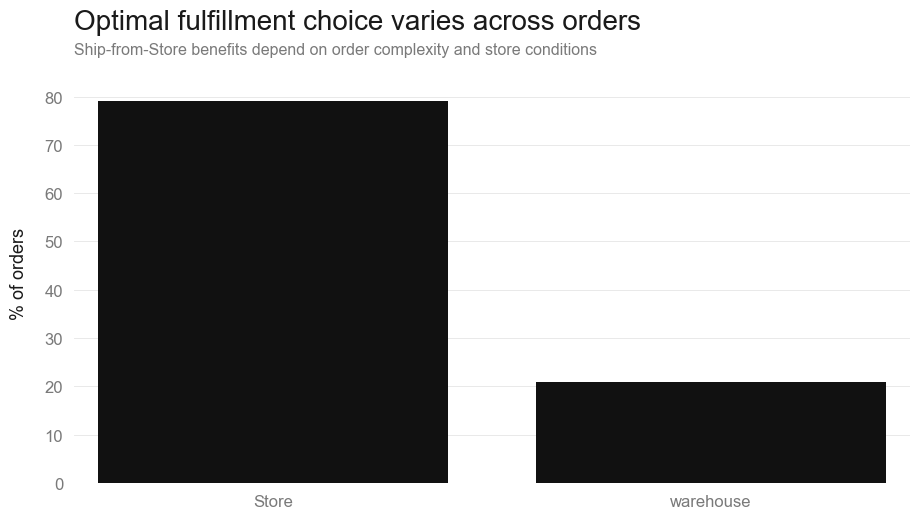

In [13]:
fig, ax = create_figure()

ax.bar(best_dist.index, best_dist.values, color=ACCENT)

add_title(
    ax,
    "Optimal fulfillment choice varies across orders",
    "Ship-from-Store benefits depend on order complexity and store conditions"
)

ax.set_ylabel("% of orders")

clean_axes(ax)

plt.tight_layout(pad=3)
plt.show()

In [14]:
# Measure impact
df_sim["risk_reduction"] = df_sim["risk_warehouse"] - df_sim["risk_store"]

df_sim["risk_reduction"].describe()

count    97005.000000
mean         0.013857
std          0.032119
min         -0.048337
25%          0.011671
50%          0.015865
75%          0.043660
max          0.048337
Name: risk_reduction, dtype: float64

In [15]:
# Average impact
impact = df_sim["risk_reduction"].mean() * 100
print(f"Average dissatisfaction reduction from using Store: {impact:.2f}%")

Average dissatisfaction reduction from using Store: 1.39%


/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_83930/1602979155.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sim.groupby("value_segment")["risk_reduction"]


<Axes: xlabel='value_segment'>

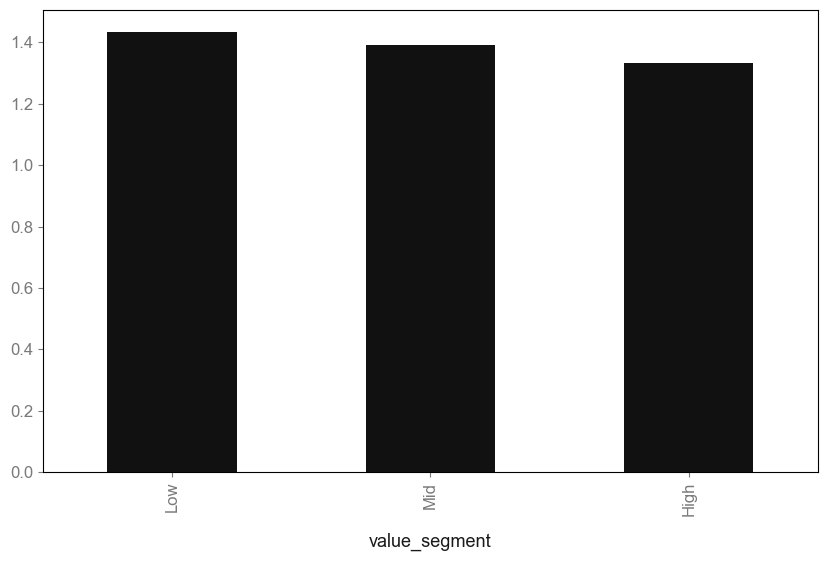

In [16]:
# By value segment
df_sim["value_segment"] = pd.qcut(df_sim["order_value"], q=3, labels=["Low", "Mid", "High"])

impact_by_value = (
    df_sim.groupby("value_segment")["risk_reduction"]
    .mean() * 100
)

impact_by_value.plot(kind="bar", color=ACCENT)

### Key Insight

Fulfillment decisions should not be optimized purely for speed or cost. The best fulfillment source depends on customer experience risk, order complexity, and operational conditions.

A CX-based fulfillment model only becomes meaningful once tradeoffs and operational constraints are introduced. Without them, the system will always default to the fastest option.

Simulation results suggest that:
- The optimal fulfillment strategy varies across orders
- Faster fulfillment (e.g., Ship-from-Store) can reduce dissatisfaction risk
- The impact is not uniform and depends on order characteristics

### Business Implication

Introducing a CX-based decision layer in fulfillment systems could help prioritize:
- high-risk orders
- high-value customers
- time-sensitive deliveries

### Limitation

This simulation uses approximated delivery scenarios and does not include real inventory or location data.

### Next Step

Integrate real-time inventory, geographic data, and logistics constraints to operationalize this decision framework.

# Estimating Business Impact

The dataset doesn’t include churn or financial loss, so I used scenario-based estimates to translate experience into business impact. The goal is not precision, but to size the opportunity and prioritize action.

### Known values from analysis
dissatisfied_late_value = 590018.66

### Churn scenarios
churn_rates = [0.05, 0.10, 0.20]

for rate in churn_rates:
    estimated_loss = dissatisfied_late_value * rate
    print(f"Churn rate: {int(rate*100)}% -> Estimated revenue impact: ${estimated_loss:,.0f}")

### Interpretation

Under conservative assumptions, a portion of revenue associated with dissatisfied customers may be at risk due to reduced repeat purchase or churn.

- At 5% churn: ~30K in potential impact  
- At 10% churn: ~60K in potential impact  
- At 20% churn: ~118K in potential impact  

These figures should be interpreted as directional estimates, not exact losses, and highlight the potential business value of improving delivery performance.

### Improvement scenario: reduce late deliveries by 20%
reduction = 0.2

prevented_value = dissatisfied_late_value * reduction

for rate in churn_rates:
    recovered = prevented_value * rate
    print(f"Recovered (at {int(rate*100)}% churn): ${recovered:,.0f}")